### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [490]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [491]:
data = pd.read_csv('data/coupons.csv')

In [492]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [493]:
null_data = data.isnull()
categorical_null_data = null_data.sum()
print("Based on the null data by column, it looks like most of the car field is null,\nwhereas 'bar', 'coffeehouse', 'carryaway', 'RestaurantLessThan20', and 'Restaurant20To50' all have some null values.")

Based on the null data by column, it looks like most of the car field is null,
whereas 'bar', 'coffeehouse', 'carryaway', 'RestaurantLessThan20', and 'Restaurant20To50' all have some null values.


3. Decide what to do about your missing data -- drop, replace, other...

In [494]:
#Since almost all of the car data is null, will drop the column
new_data = data.drop('car', axis = 1)
#for the rest of the columns, I will replace the data with the mode to preserve the other data in the row
new_data[['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']] = data[['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']].apply(lambda col: col.fillna(col.mode()[0]))


4. What proportion of the total observations chose to accept the coupon?



In [495]:
total_accept_ratio = new_data['Y'].mean() #acceptance rate
print(total_accept_ratio)
print('57% of the total observations accepted the coupons')

0.5684326710816777
57% of the total observations accepted the coupons


5. Use a bar plot to visualize the `coupon` column.

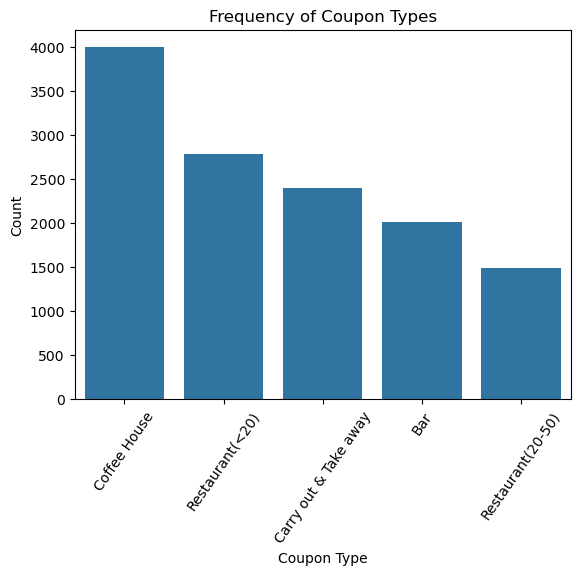

In [496]:
counts = new_data['coupon'].value_counts()
sns.barplot(x = counts.index, y = counts.values)
plt.title('Frequency of Coupon Types')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.xticks(rotation = 55)
plt.show()

6. Use a histogram to visualize the temperature column.

temperature
80    6528
55    3840
30    2316
Name: count, dtype: int64


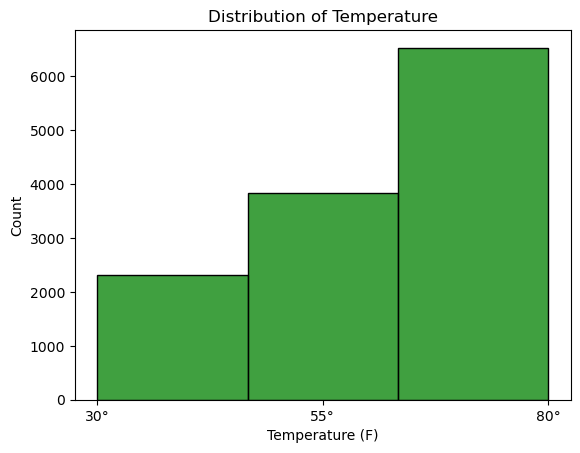

In [497]:
sns.histplot(new_data['temperature'], bins = 3, color = 'green')
plt.xlabel('Temperature (F)')
plt.xticks([30, 55, 80], ['30°', '55°', '80°']) #labels for each type of temperature
plt.title('Distribution of Temperature')
print(new_data['temperature'].value_counts())

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [498]:
bar_df = data[data['coupon'] == 'Bar']
bar_df.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1


2. What proportion of bar coupons were accepted?


In [499]:
bar_accept_ratio = bar_df['Y'].mean()
print(bar_accept_ratio * 100, " - acceptance rate of bar coupons")

41.00148735746158  - acceptance rate of bar coupons


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [500]:
#calculate frequency of 3 or less 
three_or_less = bar_df[bar_df['Bar'].isin(['never', 'less1', '1~3'])]
print(three_or_less['Y'].mean()," - acceptance rate for those who went to a bar 3 or fewer times is 37%")
#calculate frequency of more than 3 
more_than_three = bar_df[bar_df['Bar'].isin(['4~8', 'gt8'])] 
print(more_than_three['Y'].mean(), " - acceptance rate for those who went to a bar more than 3 times is 77%")

0.37061769616026713  - acceptance rate for those who went to a bar 3 or fewer times is 37%
0.7688442211055276  - acceptance rate for those who went to a bar more than 3 times is 77%


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [501]:
# avoid warnings with a copy
bar_copy = bar_df.copy()

# cleaning
bar_copy['age'] = bar_copy['age'].replace({'50plus': 50, 'below21': 20})
bar_copy['age'] = pd.to_numeric(bar_copy['age'])
bar_copy['frequency'] = bar_copy['Bar'].isin(['1~3', '4~8', 'gt8'])

# set up conditions
meets_conditions = bar_copy[(bar_copy['age'] > 25) & (bar_copy['frequency'])]
fails_conditions = bar_copy[~((bar_copy['age'] > 25) & (bar_copy['frequency']))]

acceptance_rate_1 = meets_conditions['Y'].mean()
acceptance_rate_2 = fails_conditions['Y'].mean()
print(acceptance_rate_1 * 100, " - acceptance rate of frequency of visiting the bar over once a month & over the age of 25")
print(acceptance_rate_2 * 100, " - acceptance rate of everyone else")
print("There is a huge difference here, indicating that age and frequency are good indicators of acceptance rate.")

69.52380952380952  - acceptance rate of frequency of visiting the bar over once a month & over the age of 25
33.500313087038194  - acceptance rate of everyone else
There is a huge difference here, indicating that age and frequency are good indicators of acceptance rate.


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [502]:
#frequency greater than 1, doesn't have kids, doesn't have agricultural occupation
meets_conditions_one = bar_copy[(bar_copy['Bar'].isin(['1~3', '4~8', 'gt8'])) & (~bar_copy['passanger'].isin(['Kid(s)'])) & (~bar_copy['occupation'].isin(['Farming Fishing & Forestry']))]
#everybody else
fails_conditions_one = bar_copy[~(bar_copy['Bar'].isin(['1~3', '4~8', 'gt8'])) & (~bar_copy['passanger'].isin(['Kid(s)'])) & (~bar_copy['occupation'].isin(['Farming Fishing & Forestry']))]

#Calculating the means
acceptance_rate_3 = meets_conditions_one['Y'].mean()
acceptance_rate_4 = fails_conditions_one['Y'].mean()

print(acceptance_rate_3 * 100, " - acceptance rate of frequency of visiting the bar over once a month, had passengers that were not kids, and weren't farmers,\nfishers, or foresters.")
print(acceptance_rate_4 * 100, " - acceptance rate of everyone else\n")
print("The difference between these two acceptance rates is huge, indicating that individuals with no kids and no agricultural occupation that frequented the bar more than once a month had more of a chance of accepting the bar coupons than those who didn't fall into that category. ")
print("This tells me that occupation and passenger type play a huge role in determining bar coupon acceptance rates")

71.32486388384754  - acceptance rate of frequency of visiting the bar over once a month, had passengers that were not kids, and weren't farmers,
fishers, or foresters.
30.94098883572568  - acceptance rate of everyone else

The difference between these two acceptance rates is huge, indicating that individuals with no kids and no agricultural occupation that frequented the bar more than once a month had more of a chance of accepting the bar coupons than those who didn't fall into that category. 
This tells me that occupation and passenger type play a huge role in determining bar coupon acceptance rates


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [503]:
#bars more than once a month, had passengers that were not a kid, and were not widowed 
condition1 = bar_copy[(bar_copy['Bar'].isin(['1~3', '4~8', 'gt8'])) & (~bar_copy['passanger'].isin(['Kid(s)'])) & (~bar_copy['maritalStatus'].isin(['Widowed']))]
#bars more than once a month and are under the age of 30
condition2 = bar_copy[(bar_copy['Bar'].isin(['1~3', '4~8', 'gt8'])) & (bar_copy['age'] < 30)]
#cheap restaurants more than 4 times a month and income is less 50K 
condition3 = bar_copy[(bar_copy['RestaurantLessThan20'].isin(['4~8', 'gt8'])) & (bar_copy['income'].isin(['Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999']))]
print(condition1['Y'].mean() * 100, " - acceptance rate of frequency of visiting the bar over once a month , had passengers that weren't kids, and were not widowed")
print(condition2['Y'].mean()* 100, " - acceptance rate of frequency of visiting the bar over once a month and under the age of 30")
print(condition3['Y'].mean() * 100, " - acceptance rate of frequency of visiting a cheap restaurant more than 4 times and income less than 50,000$")

71.32486388384754  - acceptance rate of frequency of visiting the bar over once a month , had passengers that weren't kids, and were not widowed
72.17391304347827  - acceptance rate of frequency of visiting the bar over once a month and under the age of 30
45.348837209302324  - acceptance rate of frequency of visiting a cheap restaurant more than 4 times and income less than 50,000$


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

Since 41% of the bar coupons were accepted overall, I am going to use this value as a baseline for comparisons. The main variable that drove acceptance rates of the bar coupon was frequency. Drivers who frequented the bar more than 3 times far exceeded the average acceptance rate, revealing how impactful frequency was as a variable. Drivers who visited the bar at any lower frequency had a 37% chance of accepting the coupon, which is below the acceptance rate for all bar coupons. Interestingly, in questions 4, 5, 6, a common variable in high acceptance rates was frequency of visiting a bar over once a month, leading me to believe that drivers who visited a bar more than once a month were more likely to buy the coupon than those who frequented the bar less than that. 

Furthermore, in question 4, we found that drivers who frequented the bar more than once a month and were over the age of 25 had a 69.5% chance of accepting the coupon. In question 6, we found that drivers who frequented the bar more than once a month and were under the age of 30 had 72% chance of accepting the coupon. This ~3% difference stands for the drivers who aren't between the ages of 25 and 30, revealing how the bulk of acceptances lie within the range 25-30 years old. Thus, age plays a huge role in the acceptance rate as well. 

Finally, I wanted to point out how the acceptance rate for drivers who visited the bar over once a month, had passengers that weren't kids, and were not widowed was the exact SAME as the acceptance rate for drivers who visited the bar over once a month, had passengers that weren't kids, and weren't farmers, fishers, or foresters. This means that acceptance rate for drivers who visited a bar over once a month and had passengers that weren't kids is independent of whether the driver is widowed or an agricultural worker. 

Moving forward, I would want to calculate the acceptance rate of drivers who aren't in the 25-30 age range and see if it is signficantally small. This would prove that frequent bar goers who are between the ages of 25 and 30 are a good target audience for this coupon. Secondly, I would like to compare the acceptance rates of drivers who are widowed to those who are not (same with drivers who work in the agricultural industry to those who don't) to see whether there is a difference. If there is a difference, these variables actually do affect acceptance and must be studied more thoroughly. If there is a negligible difference, it is safe to say that being widowed or working in the agricultural industry is not a good indicator for acceptance rate, meaning that we don't have to worry about these demographics. 

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [504]:
#Chosen Group: Coffee House
coffee_df = data[data['coupon'] == 'Coffee House']
coffee_df.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
12,No Urgent Place,Kid(s),Sunny,55,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
15,Home,Alone,Sunny,80,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0


In [505]:
#Check for overall acceptance rate
coffee_acceptance = coffee_df['Y'].mean()
print(coffee_acceptance * 100, " - acceptance rate of coffee house coupons")

49.92492492492492  - acceptance rate of coffee house coupons


In [506]:
#1 or fewer times per month vs more than 1
LT1 = coffee_df[coffee_df['CoffeeHouse'].isin(['never', 'less1'])]['Y'].mean()
GT1 = coffee_df[coffee_df['CoffeeHouse'].isin(['1~3', '4~8', 'gt8'])]['Y'].mean()

print(LT1 * 100, ' - acceptance rate of those who frequented the coffee house less than once per month')
print(GT1 * 100, ' - acceptance rate of those who frequented the coffee house more than once per month')
print("Clearly, drivers who frequent the coffee house more than once per month tend to accept the coupon more than those who don't frequent the coffee house\nthat much.")

34.61538461538461  - acceptance rate of those who frequented the coffee house less than once per month
66.02497398543184  - acceptance rate of those who frequented the coffee house more than once per month
Clearly, drivers who frequent the coffee house more than once per month tend to accept the coupon more than those who don't frequent the coffee house
that much.


In [507]:
#time traveled to coupon
GEQ5 = coffee_df[(coffee_df['toCoupon_GEQ5min'] == 1) & (coffee_df['CoffeeHouse'].isin(['1~3', '4~8', 'gt8']))]['Y'].mean() #at least 5 min drive
GEQ15 = coffee_df[(coffee_df['toCoupon_GEQ15min'] == 1) & (coffee_df['CoffeeHouse'].isin(['1~3', '4~8', 'gt8']))]['Y'].mean()#at least 15 min drive
GEQ25 = coffee_df[coffee_df['toCoupon_GEQ25min'] == 1 & (coffee_df['CoffeeHouse'].isin(['1~3', '4~8', 'gt8']))]['Y'].mean()#at least 25 min drive
print(GEQ5 * 100, " - coupon acceptance rate of driver going to coffee shops more than once a month and location is at least 5 minutes away")
print(GEQ15 * 100, " - coupon acceptance rate of driver going to coffee shops more than once a month and location is at least 15 minutes away")
print(GEQ25 * 100, " - coupon acceptance rate of driver going to coffee shops more than once a month and location is at least 25 minutes away")
print("GEQ5 and GEQ15 revealed higher acceptance rates than GEQ25. These calculations suggest that drivers will accept the coupon if the time needed to drive to the coffee shop is short")

66.02497398543184  - coupon acceptance rate of driver going to coffee shops more than once a month and location is at least 5 minutes away
58.75875875875876  - coupon acceptance rate of driver going to coffee shops more than once a month and location is at least 15 minutes away
36.76328502415459  - coupon acceptance rate of driver going to coffee shops more than once a month and location is at least 25 minutes away
GEQ5 and GEQ15 revealed higher acceptance rates than GEQ25. These calculations suggest that drivers will accept the coupon if the time needed to drive to the coffee shop is short


In [508]:
#time of day
early_morning = coffee_df[(coffee_df['time'].isin(['7AM'])) & (coffee_df['CoffeeHouse'].isin(['1~3', '4~8', 'gt8']))]['Y'].mean()
morning = coffee_df[(coffee_df['time'].isin(['10AM'])) & (coffee_df['CoffeeHouse'].isin(['1~3', '4~8', 'gt8']))]['Y'].mean()
afternoon = coffee_df[(coffee_df['time'].isin(['2PM'])) & (coffee_df['CoffeeHouse'].isin(['1~3', '4~8', 'gt8']))]['Y'].mean()
night = coffee_df[(coffee_df['time'].isin(['6PM']))& (coffee_df['CoffeeHouse'].isin(['1~3', '4~8', 'gt8']))]['Y'].mean()
print(early_morning * 100, " - coupon acceptance rate of driver frequenting coffee house more than once a month and the time being 7AM")
print(morning * 100, " - coupon acceptance rate of driver frequenting coffee house more than once a month and the time being 10AM" )
print(afternoon * 100, " - coupon acceptance rate of driver frequenting coffee house more than once a month and the time being 2PM")
print(night * 100, " - coupon acceptance rate of driver frequenting coffee house more than once a month and the time being 6PM")
print("The acceptance rate for drivers who frequent coffee houses more than once a month (~66%) decreases if the time the coupon is sent is at 7AM or 6PM")
print("On the flip side, the acceptance rate for drivers with the same frequency condition goes up if the coupon is sent at either 10AM or 2PM.")

59.09090909090909  - coupon acceptance rate of driver frequenting coffee house more than once a month and the time being 7AM
81.29496402877699  - coupon acceptance rate of driver frequenting coffee house more than once a month and the time being 10AM
73.3502538071066  - coupon acceptance rate of driver frequenting coffee house more than once a month and the time being 2PM
58.679245283018865  - coupon acceptance rate of driver frequenting coffee house more than once a month and the time being 6PM
The acceptance rate for drivers who frequent coffee houses more than once a month (~66%) decreases if the time the coupon is sent is at 7AM or 6PM
On the flip side, the acceptance rate for drivers with the same frequency condition goes up if the coupon is sent at either 10AM or 2PM.


The coupon acceptance rate for coffeehouses is about 50% (baseline). Categorizing the data based on frequency revealed that the acceptance rate of coupons for drivers who frequent coffee houses more than once a month was ~66%, a huge leap from the baseline. Further queries revealed that the time it takes to drive to the coffee house matters, with higher times getting lower acceptance rates. This makes sense because the act of buying coffee is quick for most people, making further destinations less appealing to drivers who are going about their busy schedules. Interestingly enough, coupons that were sent out at 10AM or 2PM to drivers who frequented coffee houses more than once per month had acceptance rates of 81% and 73%, respectively. This makes sense because individuals are most likely getting tired or trying to re-up on coffee around these times. 81% acceptance rate is really impressive, suggesting that coupon companies should target individuals who frequent coffee houses more than once a month by sending them coupons around 10AM. 

Based of this, future steps would include partitioning the data to reflect that 81% (i.e. more than once a month and 10AM coupons). From here, I would begin manipulating the data to see what increases that number in order to get the highest conditional acceptance rate. 